In [18]:
import ipywidgets as widgets
import pyarrow as pa
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import base64
from io import BytesIO
from PIL import Image
import json
import uuid

In [13]:
class Sample:
    def __init__(self, source_name):
        self.images = {}
        self.videos = []
        self.messages = [{"role": "system", "content": "You are a helpful assistant."}]
        self.source_name = source_name
    
    def user_msg(self, text, image=None, video=None):
        msg = {
            "role": "user",
            "content": []
        }
        if image is not None:
            with open(image, "rb") as fp:
                image_bytes = fp.read()
                image_idx = len(self.images)
                self.images[f"image_{image_idx}"] = base64.b64encode(image_bytes).decode('ascii')
                
            msg["content"].append({
                "type": "image", 
                "image": f"image_{image_idx}"
            })
        if video is not None:
            msg["content"].append({
                "type": "video", 
                "video": video
            })
            self.videos.append(video)
            
        msg["content"].append({
            "type": "text", 
            "text": text
        })
        self.messages.append(msg)
    
    def response_msg(self, text):
        msg = {
            "role": "assistant", 
            "content": text
        }
        self.messages.append(msg)
    
    def gen_sample(self):
        sample = {
            "images": json.dumps(self.images),
            "videos": json.dumps(self.videos),
            "source": self.source_name,
            "messages": json.dumps(self.messages),
            "segments": json.dumps(None),
            "metadata": None,
            "uuid": str(uuid.uuid1()),
        }
        return sample

In [37]:
def decode_base64_image(base64_string):
    # 解码base64字符串并返回PIL图像对象
    image_data = base64.b64decode(base64_string)
    image = Image.open(BytesIO(image_data))
    return image

def format_messages(messages, images):
    for msg in messages:
        msg_content = f"[{msg['role']}]: "
        if isinstance(msg["content"], str):
            msg_content += msg["content"]
        else:
            for content in msg["content"]:
                if content["type"] == "image":
                    if msg_content != "":
                        print(msg_content)
                        msg_content = ""
                    name = content["image"]
                    image = images[name]
                    display(name, image.size, image)
                elif content["type"] == "text":
                    msg_content += content["text"]
                elif content["type"] == "video":
                    print(content)
        if msg_content != "":
            print(msg_content)
        print("-" * 10)

def format_segments(segments, images):
    for seg in segments:
        if seg["type"] == "text":
            print(seg["text"] + "\n")
        elif seg["type"] == "image":
            name = seg["image"]
            image = images[name]
            display(name, image.size, image)
            

def display_sample(sample):
    source = sample['source']
    images = json.loads(sample.pop('images'))
    messages = json.loads(sample['messages'])
    segments = json.loads(sample['segments'])
    for name, base64_string in images.items():
        image = decode_base64_image(base64_string)
        images[name] = image

    print(f"source={source}, img_nums={len(images)}")
    if segments is not None:
        print("segments sample. Content:")
        print("=" * 10)
        format_segments(segments, images)
    elif messages is not None:
        print("message sample. Content:")
        print("=" * 10)
        format_messages(messages, images)

source=test, img_nums=1
message sample. Content:
[system]: You are a helpful assistant.
----------
[user]: 


'image_0'

(587, 398)

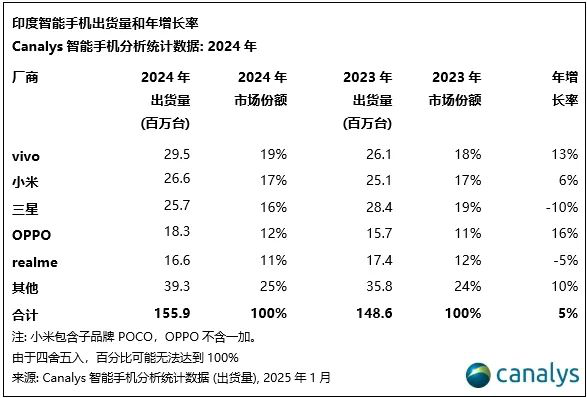

你好
----------
[assistant]: 你好
----------


In [56]:
s = Sample(source_name="test")
s.user_msg("你好", image="0ba3bda9-b5a6-4560-8ad4-0fd1c255575e.jpg")
s.response_msg("你好")
jstr = json.dumps(s.gen_sample())

display_sample(s.gen_sample())